In [57]:
import pandas as pd
import import_ipynb
import numpy as np
import PossionModel
import atkDefModel
import ElevationModel
import matplotlib.pyplot as plt
import math
import statsmodels.api as sm


            team   elo_rating
5           peru  1656.539480
3         brazil  1588.488190
12   netherlands  1578.798077
20       iceland  1576.627401
17      ethiopia  1566.018098
0       thailand  1564.280516
30      pakistan  1560.441020
6          china  1546.610633
19   philippines  1527.650728
31  saudi_arabia  1524.461826
15        panama  1519.027499
2         serbia  1514.871802
4          india  1513.088188
29           usa  1505.086390
13     indonesia  1501.059959
18        rwanda  1495.928348
27          oman  1490.366289
9    south_korea  1488.868327
8      guatemala  1488.776438
28   new_zealand  1488.316567
24            uk  1473.977378
1    switzerland  1473.564718
26     singapore  1461.772207
14        mexico  1461.357285
11        canada  1455.241835
25        france  1448.033981
22       vietnam  1445.881564
23       morocco  1437.718962
7        germany  1430.038593
21           uae  1421.171760
10      mongolia  1417.994839
16    kazakhstan  1377.941102


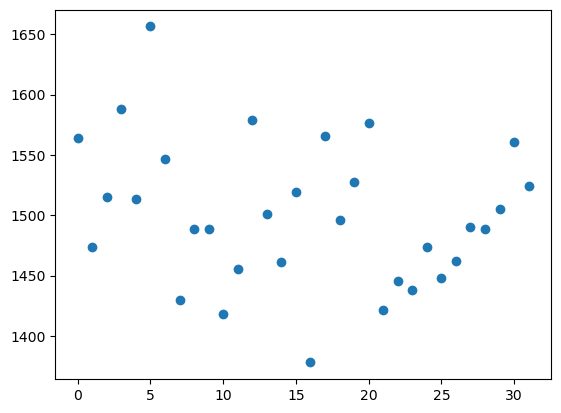

In [ ]:
elo = 1500

p = 0.4794207317073171
elev_adj_pts = 400 * math.log10(p / (1 - p))

file = "League Table (2026).xlsx"

df = pd.read_excel(file, sheet_name="Base")

elo_ratings = {t: 1500.0 for t in pd.unique(pd.concat([df["home_team"], df["away_team"]]))}

K = 20
home_adv_pts = 0.0

def expected_score(home_elo, away_elo, home_adv_pts=0.0, elev_adj_home_pts=0.0):
    d = (home_elo + home_adv_pts + elev_adj_home_pts) - away_elo
    return 1 / (1 + 10 ** (-d / 400))

def poisson_pmf(lam, max_g):
    g = np.arange(max_g + 1)
    pmf = np.exp(-lam) * lam**g / np.array([math.factorial(int(k)) for k in g])
    return pmf

def winprob_from_lambdas_hockey(lam_h, lam_a, max_g=12, ot_home=0.5):
    """
    Returns P(home wins including OT/SO), using:
    P(win) = P(H>A) + ot_home * P(H=A)
    """
    pH = poisson_pmf(lam_h, max_g)
    pA = poisson_pmf(lam_a, max_g)
    M = np.outer(pH, pA)

    p_home_reg = np.tril(M, -1).sum()   # i>j
    p_tie_reg  = np.trace(M)            # i=j
    p_away_reg = np.triu(M,  1).sum()   # j>i

    s = p_home_reg + p_tie_reg + p_away_reg  
    p_home_reg /= s
    p_tie_reg  /= s

    return p_home_reg + ot_home * p_tie_reg

def elo_update(home_elo, away_elo, S_home, E_home, K=20):
    home_new = home_elo + K * (S_home - E_home)
    away_new = away_elo + K * ((1 - S_home) - (1 - E_home))  # symmetric
    return home_new, away_new
HOME_ADV_PTS = 50.0

for _, row in df.iterrows():
    
    p0 = winprob_from_lambdas_hockey(lam_h, lam_a, max_g=12, ot_home=0.5)
    home = row["home_team"]
    away = row["away_team"]

    hg = int(row["sum home_goals"])
    ag = int(row["sum away_goals"])
    S_home = 1.0 if hg > ag else 0.0  # assumes no ties in your final score data

    lam_h, lam_a = PossionModel.predict_lambdas_teamwise(home, away)
    p_home = winprob_from_lambdas_hockey(lam_h, lam_a, max_g=12, ot_home=0.5)

    # clamp to avoid log blowups
    eps = 1e-6
    p_home = min(max(p_home, eps), 1 - eps)

    # OPTIONAL: elevation adjustment as an Elo-points shift on logit scale
    elev_penalty_pts = 400 * math.log10(p / (1 - p))  # whatever your chosen p is
    home_e = ElevationModel.elev_index(home)
    away_e = ElevationModel.elev_index(away)

    if home_e < away_e:
        dRelev = elev_penalty_pts
    elif away_e < home_e:
        dRelev = -elev_penalty_pts
    else:
        dRelev = 0.0

    # Convert poisson probability into "poisson rating difference"
    dR_poisson = 400 * math.log10(p_home / (1 - p_home))

    # Combine with elevation 
    dR_adj = dR_poisson + dRelev

    # Back to expected probability
    p = (df["sum home_goals"] > df["sum away_goals"]).mean()

    HOME_ADV_PTS = 400 * math.log10(p / (1 - p))
    
    E_home = expected_score(elo_ratings[home], elo_ratings[away],
                            home_adv_pts=HOME_ADV_PTS,
                            elev_adj_home_pts=dRelev)

    elo_ratings[home], elo_ratings[away] = elo_update(
        elo_ratings[home], elo_ratings[away], S_home, E_home, K=K
    )

print(pd.DataFrame(list(elo_ratings.items()), columns=["team", "elo_rating"]).sort_values(by="elo_rating", ascending=False).iloc[:32])

y = pd.DataFrame(list(elo_ratings.items()), columns=["team", "elo_rating"])["elo_rating"].values
X = pd.DataFrame(list(elo_ratings.items()), columns=["team", "elo_rating"])
plt.scatter(range(len(X)), X["elo_rating"])
plt.show()
